# DAAN 545 — Frequent Pattern / Association Rule Mining

**Goal (P1):** Turn the cleaned delay panel into many **binary items**, then run `apriori`, `fpgrowth`, and `association_rules` from **mlxtend**.

**Input:** `data/processed/airline_delay_cause_with_airports.csv` (BTS delays + OpenFlights geography).

**Approach:**
1. Discretize continuous fields with inequalities (e.g. `pct_delayed >= Q75`)
2. One-hot categoricals (`census_region`, `tz_group`, top carriers/airports)
3. Mine frequent itemsets with apriori **and** fpgrowth
4. Generate association rules; vary `min_support` and discuss patterns


## 0. Setup

Helpers live in `src/association_rules.py` (`build_transaction_matrix`) so the same binary encoding can be reused later.


In [8]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path.cwd()
if not (ROOT / "data" / "processed").exists():
    ROOT = ROOT.parent

DATA_PROCESSED = ROOT / "data" / "processed"
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.association_rules import build_transaction_matrix

print(f"Project root: {ROOT}")


Project root: c:\Users\MLMir\Projects\DAAN545-flight-delay-analysis


## 1. Load enriched panel

Same monthly grain as EDA: **carrier × airport × year × month**.


In [9]:
PANEL_PATH = DATA_PROCESSED / "airline_delay_cause_with_airports.csv"
df = pd.read_csv(PANEL_PATH)
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns from {PANEL_PATH.name}")
df.head(3)


Loaded 8,963 rows × 43 columns from airline_delay_cause_with_airports.csv


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,timezone_offset,tz,tz_group,state,census_region,hub_size,hub_code,enplanements_cy23,slot_controlled,runway_count
0,2026,6,MQ,Envoy Air,MSP,"Minneapolis, MN: Minneapolis-St Paul International",85.0000,11.0000,1.6300,0.7000,...,-6.0000,America/Chicago,Central,MN,Midwest,Large,L,17019128,False,4
1,2026,6,MQ,Envoy Air,ORD,"Chicago, IL: Chicago O'Hare International","4,737.0000",926.0000,188.1100,101.8800,...,-6.0000,America/Chicago,Central,IL,Midwest,Large,L,35843104,False,8
2,2026,6,MQ,Envoy Air,PHX,"Phoenix, AZ: Phoenix Sky Harbor International","1,035.0000",168.0000,58.1500,3.8700,...,-7.0000,America/Phoenix,Mountain,AZ,West,Large,L,23880504,False,3


## 2. Create binary / one-hot / discretized items

| Kind | Examples |
|------|----------|
| Discretize | `high_delay` (pct_delayed ≥ Q75), `high_cancel`, `*_dominant` cause shares ≥ 35% |
| Season | `is_winter`, `is_spring`, `is_summer`, `is_fall` |
| One-hot | `region_*`, `tz_*`, top carriers / airports |
| Geography | `high_altitude` (≥ 3000 ft), `northern` (lat ≥ median) |

These are the “baskets”: each row is a transaction; each `True` column is an item in that basket.


In [10]:
binary, meta = build_transaction_matrix(df)

print("=== Binary matrix ===")
print(f"Rows (transactions): {meta['n_rows']:,}")
print(f"Items (binary columns): {meta['n_items']}")
print(f"high_delay cutoff (Q{meta['delay_q']:.2f}): {meta['delay_cut_pct']:.2f}% delayed")
print(f"high_cancel cutoff (Q{meta['cancel_q']:.2f}): {meta['cancel_cut_pct']:.2f}% cancelled")
print(f"Cause-dominant share threshold: {meta['cause_share_threshold']:.0%}")
print(f"High-altitude cutoff: {meta['high_altitude_ft']:.0f} ft")
print(f"Northern lat median: {meta['lat_median']:.2f}")

print("\nItem support (fraction of rows = True):")
display(meta["item_support"].to_frame("support"))

# Persist for the report / teammates
out_bin = DATA_PROCESSED / "association_binary_matrix.csv"
binary.astype(int).to_csv(out_bin, index=False)
print(f"\nSaved binary matrix → {out_bin}")
binary.head()


=== Binary matrix ===
Rows (transactions): 8,963
Items (binary columns): 44
high_delay cutoff (Q0.75): 28.22% delayed
high_cancel cutoff (Q0.75): 2.27% cancelled
Cause-dominant share threshold: 35%
High-altitude cutoff: 3000 ft
Northern lat median: 38.85

Item support (fraction of rows = True):


,support
hub_Large,1.0000
many_runways,0.6393
late_aircraft_dominant,0.5411
northern,0.5009
tz_Eastern,0.4991
region_South,0.4436
carrier_dominant,0.3710
is_summer,0.2807
region_West,0.2534
high_delay,0.2500



Saved binary matrix → c:\Users\MLMir\Projects\DAAN545-flight-delay-analysis\data\processed\association_binary_matrix.csv


,high_delay,high_cancel,carrier_dominant,weather_dominant,nas_dominant,security_dominant,late_aircraft_dominant,is_winter,is_spring,is_summer,...,airport_DEN,airport_DFW,airport_EWR,airport_JFK,airport_LAX,airport_LGA,airport_MIA,airport_ORD,airport_SEA,airport_SFO
0,False,False,False,False,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,True,False
4,False,False,True,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


## 3. Frequent itemsets — apriori vs fpgrowth

Both algorithms find the same frequent itemsets for a given `min_support` (on boolean data). We run **both** as required, then compare counts / top patterns.

Start with `min_support=0.05` (itemset in ≥5% of rows).


In [11]:
MIN_SUPPORT = 0.05

freq_apriori = apriori(binary, min_support=MIN_SUPPORT, use_colnames=True)
freq_apriori["length"] = freq_apriori["itemsets"].apply(len)
freq_apriori = freq_apriori.sort_values("support", ascending=False).reset_index(drop=True)

freq_fp = fpgrowth(binary, min_support=MIN_SUPPORT, use_colnames=True)
freq_fp["length"] = freq_fp["itemsets"].apply(len)
freq_fp = freq_fp.sort_values("support", ascending=False).reset_index(drop=True)

print(f"min_support = {MIN_SUPPORT}")
print(f"Apriori itemsets:  {len(freq_apriori):,}")
print(f"FP-Growth itemsets:{len(freq_fp):,}")
print(f"Same itemset count: {len(freq_apriori) == len(freq_fp)}")

# Set equality check (order-independent)
set_a = set(frozenset(s) for s in freq_apriori["itemsets"])
set_f = set(frozenset(s) for s in freq_fp["itemsets"])
print(f"Identical itemset collections: {set_a == set_f}")

print("\nTop 15 apriori itemsets:")
display(freq_apriori.head(15))
print("Top multi-item FP-Growth itemsets (length ≥ 2):")
display(freq_fp.query("length >= 2").head(15))


min_support = 0.05
Apriori itemsets:  667
FP-Growth itemsets:667
Same itemset count: True
Identical itemset collections: True

Top 15 apriori itemsets:


,support,itemsets,length
0,1.0000,frozenset({hub_Large}),1
1,0.6393,frozenset({many_runways}),1
2,0.6393,"frozenset({hub_Large, many_runways})",2
3,0.5411,"frozenset({late_aircraft_dominant, hub_Large})",2
4,0.5411,frozenset({late_aircraft_dominant}),1
5,0.5009,"frozenset({hub_Large, northern})",2
6,0.5009,frozenset({northern}),1
7,0.4991,frozenset({tz_Eastern}),1
8,0.4991,"frozenset({hub_Large, tz_Eastern})",2
9,0.4436,"frozenset({region_South, hub_Large})",2


Top multi-item FP-Growth itemsets (length ≥ 2):


,support,itemsets,length
2,0.6393,"frozenset({hub_Large, many_runways})",2
3,0.5411,"frozenset({late_aircraft_dominant, hub_Large})",2
6,0.5009,"frozenset({hub_Large, northern})",2
8,0.4991,"frozenset({hub_Large, tz_Eastern})",2
9,0.4436,"frozenset({region_South, hub_Large})",2
11,0.3710,"frozenset({hub_Large, carrier_dominant})",2
13,0.3524,"frozenset({late_aircraft_dominant, hub_Large, many_runways})",3
14,0.3524,"frozenset({late_aircraft_dominant, many_runways})",2
15,0.3379,"frozenset({hub_Large, many_runways, northern})",3
16,0.3379,"frozenset({many_runways, northern})",2


## 4. Association rules

Generate rules from the FP-Growth itemsets (same as apriori here). Focus on **lift > 1** (positive association) and readable antecedents/consequents involving delay outcomes.


In [12]:
MIN_CONFIDENCE = 0.30

rules = association_rules(freq_fp, metric="confidence", min_threshold=MIN_CONFIDENCE)
rules["antecedent_len"] = rules["antecedents"].apply(len)
rules["consequent_len"] = rules["consequents"].apply(len)
rules = rules.sort_values(["lift", "confidence"], ascending=False).reset_index(drop=True)

print(f"Rules with confidence ≥ {MIN_CONFIDENCE}: {len(rules):,}")
print(f"Rules with lift > 1: {(rules['lift'] > 1).sum():,}")

# Prefer rules that say something about delays / causes
delay_like = {"high_delay", "high_cancel", "weather_dominant", "carrier_dominant",
              "nas_dominant", "late_aircraft_dominant", "security_dominant"}
mask_delay = rules["consequents"].apply(lambda s: bool(set(s) & delay_like)) | rules[
    "antecedents"
].apply(lambda s: bool(set(s) & delay_like))
rules_delay = rules.loc[mask_delay].copy()

print(f"Rules touching a delay/cause item: {len(rules_delay):,}")
display(
    rules_delay[
        ["antecedents", "consequents", "support", "confidence", "lift", "leverage", "conviction"]
    ].head(20)
)

rules_path = DATA_PROCESSED / "association_rules_min_support_0_05.csv"
# frozensets → readable strings for CSV
export = rules_delay.copy()
export["antecedents"] = export["antecedents"].apply(lambda s: ", ".join(sorted(s)))
export["consequents"] = export["consequents"].apply(lambda s: ", ".join(sorted(s)))
export.to_csv(rules_path, index=False)
print(f"Saved delay-related rules → {rules_path}")


Rules with confidence ≥ 0.3: 2,985
Rules with lift > 1: 2,181
Rules touching a delay/cause item: 1,843


c:\Users\MLMir\Projects\DAAN545-flight-delay-analysis\.venv\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:184: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


,antecedents,consequents,support,confidence,lift,leverage,conviction
219,"frozenset({tz_Central, late_aircraft_dominant, many_runways, northern})",frozenset({region_Midwest}),0.0525,1.0000,7.2050,0.0453,inf
220,"frozenset({tz_Central, late_aircraft_dominant, northern})","frozenset({region_Midwest, many_runways})",0.0525,1.0000,7.2050,0.0453,inf
221,"frozenset({late_aircraft_dominant, tz_Central, hub_Large, northern})",frozenset({region_Midwest}),0.0525,1.0000,7.2050,0.0453,inf
222,"frozenset({tz_Central, late_aircraft_dominant, northern})","frozenset({hub_Large, region_Midwest})",0.0525,1.0000,7.2050,0.0453,inf
223,"frozenset({tz_Central, late_aircraft_dominant, northern})",frozenset({region_Midwest}),0.0525,1.0000,7.2050,0.0453,inf
224,"frozenset({northern, tz_Central, hub_Large, late_aircraft_dominant, many_runways})",frozenset({region_Midwest}),0.0525,1.0000,7.2050,0.0453,inf
225,"frozenset({late_aircraft_dominant, tz_Central, hub_Large, northern})","frozenset({region_Midwest, many_runways})",0.0525,1.0000,7.2050,0.0453,inf
226,"frozenset({tz_Central, late_aircraft_dominant, many_runways, northern})","frozenset({hub_Large, region_Midwest})",0.0525,1.0000,7.2050,0.0453,inf
227,"frozenset({tz_Central, late_aircraft_dominant, northern})","frozenset({hub_Large, region_Midwest, many_runways})",0.0525,1.0000,7.2050,0.0453,inf
237,"frozenset({region_Midwest, many_runways})","frozenset({tz_Central, late_aircraft_dominant, northern})",0.0525,0.3786,7.2050,0.0453,1.5247


Saved delay-related rules → c:\Users\MLMir\Projects\DAAN545-flight-delay-analysis\data\processed\association_rules_min_support_0_05.csv


## 5. Vary `min_support`

How many itemsets / rules survive as we raise the bar? Lower support → more (noisier) patterns; higher → fewer, more common patterns.


c:\Users\MLMir\Projects\DAAN545-flight-delay-analysis\.venv\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:184: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)
c:\Users\MLMir\Projects\DAAN545-flight-delay-analysis\.venv\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:184: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)
c:\Users\MLMir\Projects\DAAN545-flight-delay-analysis\.venv\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:184: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)
c:\Users\MLMir\Projects\DAAN545-flight-delay-analysis\.venv\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:184: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.wher

,min_support,n_itemsets,n_rules_conf>=0.30,n_delay_related_rules
0,0.0200,2719,17340,11172
1,0.0500,667,2985,1843
2,0.0800,313,1173,594
3,0.1000,203,605,336
4,0.1500,101,293,150


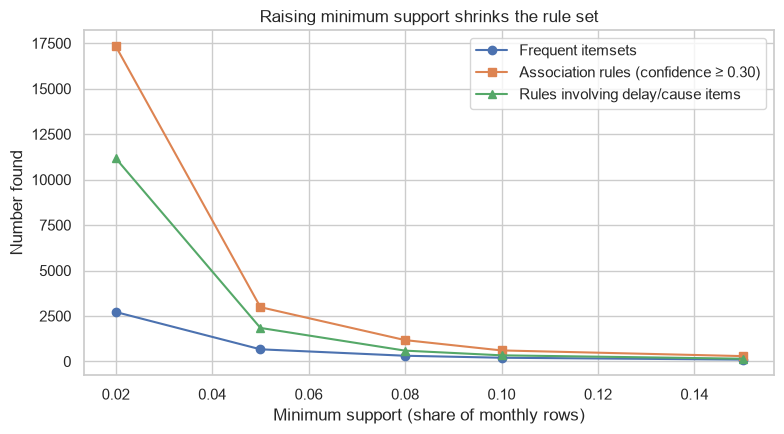

In [13]:
supports = [0.02, 0.05, 0.08, 0.10, 0.15]
sweep_rows = []
for s in supports:
    fi = fpgrowth(binary, min_support=s, use_colnames=True)
    if fi.empty:
        n_rules = 0
        n_delay_rules = 0
    else:
        r = association_rules(fi, metric="confidence", min_threshold=MIN_CONFIDENCE)
        n_rules = len(r)
        if n_rules:
            n_delay_rules = int(
                (
                    r["consequents"].apply(lambda x: bool(set(x) & delay_like))
                    | r["antecedents"].apply(lambda x: bool(set(x) & delay_like))
                ).sum()
            )
        else:
            n_delay_rules = 0
    sweep_rows.append(
        {
            "min_support": s,
            "n_itemsets": len(fi),
            "n_rules_conf>=0.30": n_rules,
            "n_delay_related_rules": n_delay_rules,
        }
    )

sweep = pd.DataFrame(sweep_rows)
display(sweep)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sweep["min_support"], sweep["n_itemsets"], marker="o", label="Frequent itemsets")
ax.plot(sweep["min_support"], sweep["n_rules_conf>=0.30"], marker="s", label="Association rules (confidence ≥ 0.30)")
ax.plot(sweep["min_support"], sweep["n_delay_related_rules"], marker="^", label="Rules involving delay/cause items")
ax.set_xlabel("Minimum support (share of monthly rows)")
ax.set_ylabel("Number found")
ax.set_title("Raising minimum support shrinks the rule set")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "09_arm_minsupport_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
